In [32]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.ticker

### Read in the excel file

In [33]:
df = pd.read_excel('ews_erg_150mMkcl_50nM.xlsx', sheet_name='Summary')
df

,Concentration,Replicate 1
0,4.500000e-01,222
1,2.250000e-01,218
2,1.125000e-01,206
3,5.625000e-02,187
4,2.812500e-02,180
5,1.406250e-02,172
6,7.031250e-03,173
7,3.515625e-03,173
8,1.757813e-03,172
9,8.789063e-04,175


Average the replicates and adjust concentrations to nmols:

In [34]:
#df['Average'] = df[['Replicate 1','Replicate 2', 'Replicate 3']].mean(axis=1)
df['Average'] = df[['Replicate 1']].mean(axis=1)
df['Concentration in nmol'] = df['Concentration'] * 1000
df.head()
df.tail()

,Concentration,Replicate 1,Average,Concentration in nmol
19,8.583069e-07,181,181.0,0.000858
20,4.291534e-07,174,174.0,0.000429
21,2.145767e-07,177,177.0,0.000215
22,1.072884e-07,174,174.0,0.000107
23,5.364418e-08,169,169.0,0.000054


In [35]:
w = widgets.Dropdown(description='Select y_data', 
                 options=df.columns)
display(w)

Dropdown(description='Select y_data', options=('Concentration', 'Replicate 1', 'Average', 'Concentration in nm…

In [36]:
y_data = df[w.value]
x_data = df['Concentration in nmol']

In [37]:
def equation(x, start, end, k, n):
    y = start + ((end - start) * (x**n / (k**n + x**n)))
    return y

## Fit curve

In [38]:
p0 = [174,251, 0.0337,3.77093]

[start, end, k, n], p_var = curve_fit(equation, 
                                      xdata=x_data, 
                                      ydata=y_data, 
                                      p0=p0);

In [39]:
print(start, end, k, n)

174.03070801371467 223.19227336954907 86.02380987318581 2.234976819894427


In [40]:
p_std = np.sqrt(np.abs(np.diag(p_var)))
p_std

array([ 0.68883844,  3.46752629, 10.68892872,  0.49479216])

## Plot fit and data

In [41]:
residuals = y_data - equation(x_data, start, end, k, n)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data-np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

In [42]:
df['log Concentration in nmol'] = np.log(df['Concentration in nmol'])

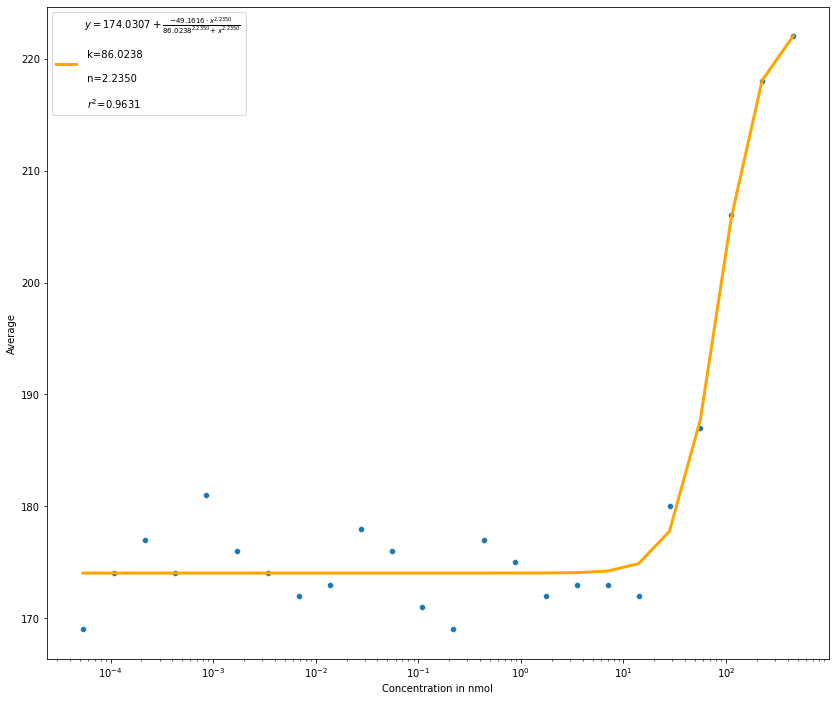

In [43]:
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot()
#fig, ax= plt.subplots()

splot = sns.scatterplot(data=df, 
                        x='Concentration in nmol',
                        y="Average",
                       )

lplot = sns.lineplot(data=df, 
                 x=x_data, 
                 y=equation(x_data, start, end, k, n),  
                 color='orange',linewidth=3,
                 label = f'$y = {start:.4f} + \\frac{{{start-end:.4f} \cdot x^{{{n:.4f}}}}}{{{k:.4f}^{{{n:.4f}}}+x^{{{n:.4f}}}}}$ \n\n k={k:.4f} \n\n n={n:.4f} \n\n $r^{2}$={r_squared:.4f}'
                )

ax.set_xscale('log')

#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)


plt.show()

## Read excel for 2nd file

In [12]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.ticker

In [13]:
df1 = pd.read_excel('erg_0th reading.xlsx', sheet_name='Summary')
df1

,Concentration,Replicate 1,Replicate 2,Replicate 3
0,14.110000,249,289,171
1,7.055000,262,271,265
2,3.527500,246,252,249
3,1.763750,241,235,238
4,0.881875,236,228,239
5,0.440937,232,233,235
6,0.220469,223,229,223
7,0.110234,215,217,222
8,0.055117,197,206,193
9,0.027559,189,187,186


In [14]:
df1['Average'] = df1[['Replicate 1','Replicate 2', 'Replicate 3']].mean(axis=1)
#df['Average'] = df[['Replicate 1']].mean(axis=1)
#df1['Average'] = df1[['Replicate 1','Replicate 2', 'Replicate 3','Replicate 4','Replicate 5','Replicate 6','Replicate 7','Replicate 8','Replicate 9','Replicate 10']].mean(axis=1)
df1['Concentration in nmol'] = df1['Concentration']*1000
df1.head()
#df1.tail()

,Concentration,Replicate 1,Replicate 2,Replicate 3,Average,Concentration in nmol
0,14.110000,249,289,171,236.333333,14110.000
1,7.055000,262,271,265,266.000000,7055.000
2,3.527500,246,252,249,249.000000,3527.500
3,1.763750,241,235,238,238.000000,1763.750
4,0.881875,236,228,239,234.333333,881.875


In [15]:
w = widgets.Dropdown(description='Select y_data', 
                 options=df1.columns)
display(w)

Dropdown(description='Select y_data', options=('Concentration', 'Replicate 1', 'Replicate 2', 'Replicate 3', '…

In [16]:
y_data_1 = df1[w.value]
x_data_1 = df1['Concentration in nmol']

In [17]:
def equation(x_1, start_1, end_1, k_1, n_1):
    y_1 = start_1 + ((end_1 - start_1) * (x_1**n_1 / (k_1**n_1 + x_1**n_1)))
    return y_1

### Fit 2nd Curve

In [18]:
p0 = [174,251, 0.0337,3.77093]

[start_1, end_1, k_1, n_1], p_var_1 = curve_fit(equation, 
                                      xdata=x_data_1, 
                                      ydata=y_data_1, 
                                      p0=p0)

In [20]:
print(start_1, end_1, k_1, n_1)

248.8782183003961 167.25858896703787 86.56026769746379 -0.9185569336524495


In [21]:
p_std_1 = np.sqrt(np.abs(np.diag(p_var_1)))
p_std_1

array([ 3.67791795,  1.78514212, 18.19841166,  0.1538739 ])

### Plot fit and data for 2nd

In [22]:
residuals_1 = y_data_1 - equation(x_data_1, start_1, end_1, k_1, n_1)
ss_res_1 = np.sum(residuals_1**2)
ss_tot_1 = np.sum((y_data_1-np.mean(y_data_1))**2)
r_squared_1 = 1 - (ss_res_1 / ss_tot_1)

In [23]:
df1['log Concentration in nmol'] = np.log(df1['Concentration in nmol'])

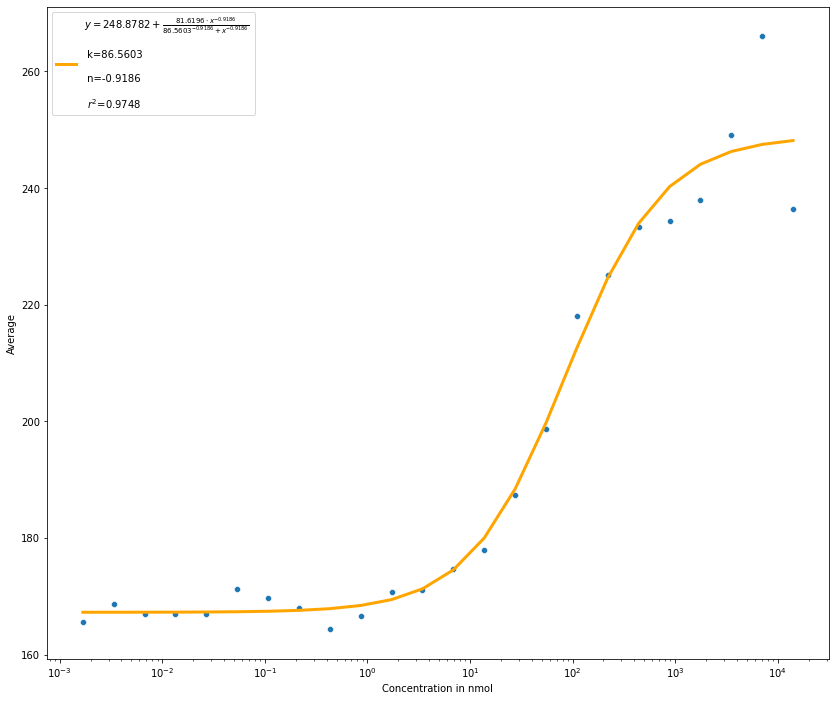

In [24]:
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot()
#fig, ax= plt.subplots()

splot = sns.scatterplot(data=df1, 
                        x='Concentration in nmol',
                        y="Average",
                       )

lplot = sns.lineplot(data=df1, 
                 x=x_data_1, 
                 y=equation(x_data_1, start_1, end_1, k_1, n_1),  
                 color='orange',linewidth=3,
                 label = f'$y = {start_1:.4f} + \\frac{{{(start_1)-(end_1):.4f} \cdot x^{{{n_1:.4f}}}}}{{{k_1:.4f}^{{{n_1:.4f}}}+x^{{{n_1:.4f}}}}}$ \n\n k={k_1:.4f} \n\n n={n_1:.4f} \n\n $r^{2}$={r_squared_1:.4f}'
                )

ax.set_xscale('log')

#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)


plt.show()

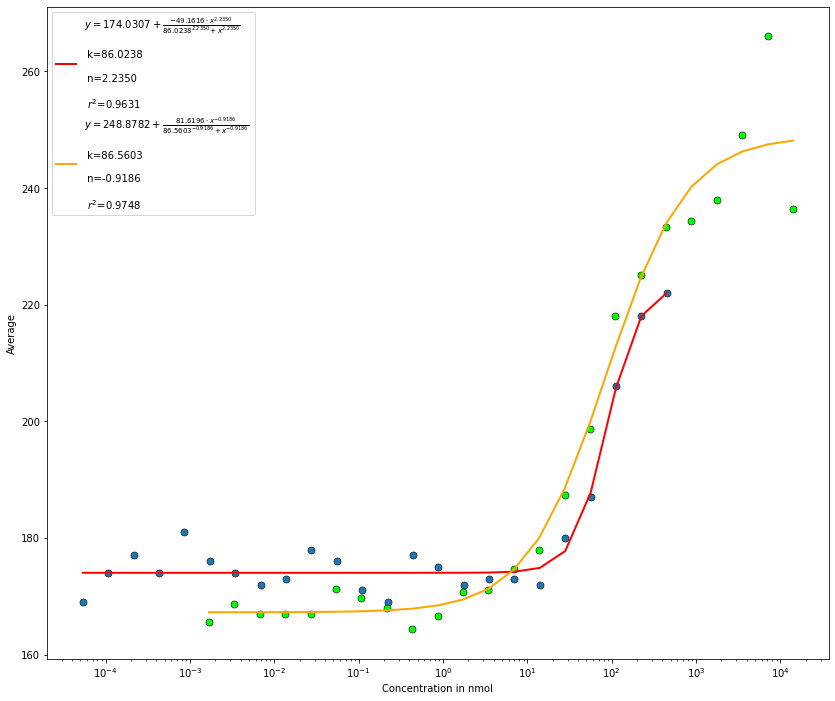

In [25]:
fig = plt.figure(figsize=(14,12),)
ax = fig.add_subplot()
#fig, ax= plt.subplots()ls='', marker='.', ms=3

splot_1 = sns.scatterplot(data=df, 
                        x='Concentration in nmol',
                        y="Average",
                        #color = '',
                        edgecolor='black',
                        s=50
                       )



lplot_1 = sns.lineplot(data=df, 
                x=x_data, 
               y=equation(x_data, start, end, k, n),  
              color='red',linewidth=2,
             label = f'$y = {start:.4f} + \\frac{{{start-end:.4f} \cdot x^{{{n:.4f}}}}}{{{k:.4f}^{{{n:.4f}}}+x^{{{n:.4f}}}}}$ \n\n k={k:.4f} \n\n n={n:.4f} \n\n $r^{2}$={r_squared:.4f}'
             )



splot = sns.scatterplot(data=df1, 
                        x='Concentration in nmol',
                        y="Average",
                         color = 'lime',
                        edgecolor='black',
                        s=50
                       )

lplot = sns.lineplot(data=df1, 
                 x=x_data_1, 
                 y=equation(x_data_1, start_1, end_1, k_1, n_1),  
                 color='orange',linewidth=2,
                 label = f'$y = {start_1:.4f} + \\frac{{{(start_1)-(end_1):.4f} \cdot x^{{{n_1:.4f}}}}}{{{k_1:.4f}^{{{n_1:.4f}}}+x^{{{n_1:.4f}}}}}$ \n\n k={k_1:.4f} \n\n n={n_1:.4f} \n\n $r^{2}$={r_squared_1:.4f}'
                )



ax.set_xscale('log')




#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)


plt.show()

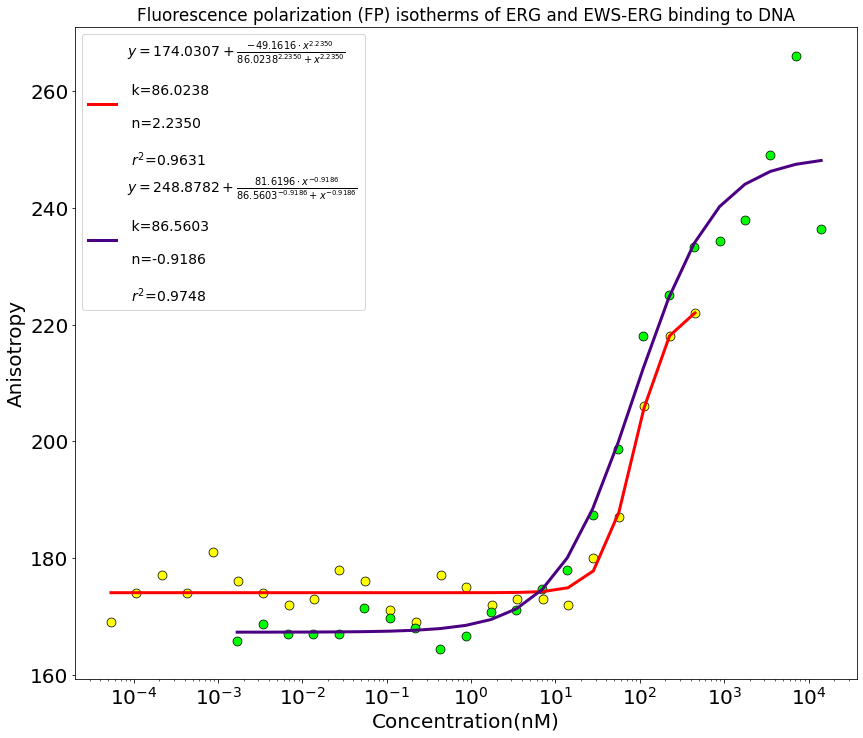

<Figure size 432x288 with 0 Axes>

In [73]:
fig = plt.figure(figsize=(14,12),)
ax = fig.add_subplot()
#fig, ax= plt.subplots()ls='', marker='.', ms=3

splot_1 = sns.scatterplot(data=df, 
                        x='Concentration in nmol',
                        y="Average",
                        color = 'yellow',
                        edgecolor='black',
                        s=80
                       )



lplot_1 = sns.lineplot(data=df, 
                x=x_data, 
               y=equation(x_data, start, end, k, n),  
              color='red',linewidth=3,
             label = f'$y = {start:.4f} + \\frac{{{start-end:.4f} \cdot x^{{{n:.4f}}}}}{{{k:.4f}^{{{n:.4f}}}+x^{{{n:.4f}}}}}$ \n\n k={k:.4f} \n\n n={n:.4f} \n\n $r^{2}$={r_squared:.4f}'
             )



splot = sns.scatterplot(data=df1, 
                        x='Concentration in nmol',
                        y="Average",
                         color = 'lime',
                        edgecolor='black',
                        s=80
                       )

lplot = sns.lineplot(data=df1, 
                 x=x_data_1, 
                 y=equation(x_data_1, start_1, end_1, k_1, n_1), 
                 color='#4b0082',linewidth=3,
                 label = f'$y = {start_1:.4f} + \\frac{{{(start_1)-(end_1):.4f} \cdot x^{{{n_1:.4f}}}}}{{{k_1:.4f}^{{{n_1:.4f}}}+x^{{{n_1:.4f}}}}}$ \n\n k={k_1:.4f} \n\n n={n_1:.4f} \n\n $r^{2}$={r_squared_1:.4f}'
                )



ax.set_xscale('log')



matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
plt.rcParams['font.size'] = '14'



#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)

# Add title and axis names
plt.title('Fluorescence polarization (FP) isotherms of ERG and EWS-ERG binding to DNA')
plt.ylabel("Anisotropy", size = 20)
plt.xlabel("Concentration(nM)", size = 20)
plt.show()



<Figure size 432x288 with 0 Axes>

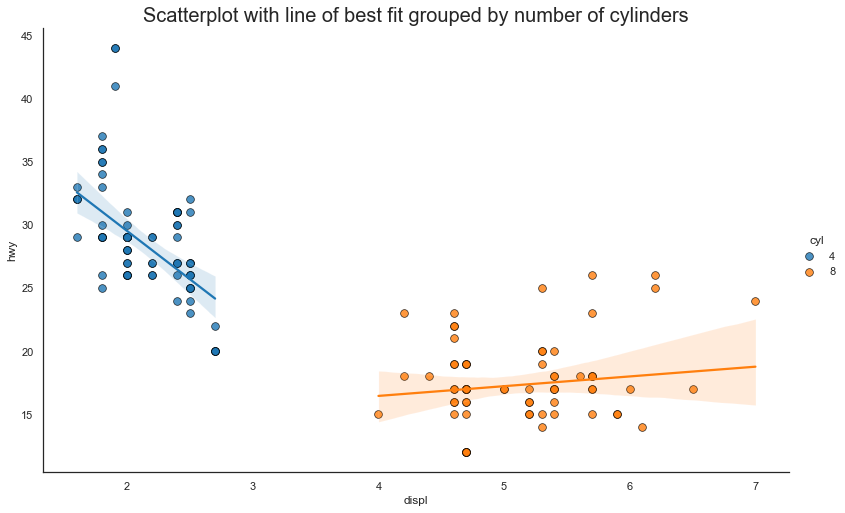

In [159]:

# Import Data
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/mpg_ggplot2.csv")
df_select = df.loc[df.cyl.isin([4,8]), :]

# Plot
sns.set_style("white")
gridobj = sns.lmplot(x="displ", y="hwy", hue="cyl", data=df_select, 
                     height=7, aspect=1.6, robust=True, palette='tab10', 
                     scatter_kws=dict(s=60, linewidths=.7, edgecolors='black'))

# Decorations
gridobj.set(xlim=(0.5, 7.5), ylim=(0, 50))
plt.title("Scatterplot with line of best fit grouped by number of cylinders", fontsize=20)
plt.show()

### Calculation for ews

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.ticker

In [2]:
df2 = pd.read_excel('ews_150mmkcl_50nM dna.xlsx', sheet_name='Summary')
df2

,Concentration,Replicate 1,Replicate 2,Replicate 3
0,4.500000e+00,191,187,182
1,2.250000e+00,187,190,183
2,1.125000e+00,178,181,180
3,5.625000e-01,183,180,178
4,2.812500e-01,177,183,176
5,1.406250e-01,182,181,187
6,7.031250e-02,180,181,184
7,3.515625e-02,183,180,186
8,1.757812e-02,192,177,182
9,8.789062e-03,186,184,179


In [3]:
df2['Average'] = df2[['Replicate 1','Replicate 2', 'Replicate 3']].mean(axis=1)
#df['Average'] = df[['Replicate 1']].mean(axis=1)
#df1['Average'] = df1[['Replicate 1','Replicate 2', 'Replicate 3','Replicate 4','Replicate 5','Replicate 6','Replicate 7','Replicate 8','Replicate 9','Replicate 10']].mean(axis=1)
df2['Concentration in nmol'] = df2['Concentration']*1000
df2.head()
#df1.tail()

,Concentration,Replicate 1,Replicate 2,Replicate 3,Average,Concentration in nmol
0,4.50000,191,187,182,186.666667,4500.00
1,2.25000,187,190,183,186.666667,2250.00
2,1.12500,178,181,180,179.666667,1125.00
3,0.56250,183,180,178,180.333333,562.50
4,0.28125,177,183,176,178.666667,281.25


In [4]:
w = widgets.Dropdown(description='Select y_data', 
                 options=df2.columns)
display(w)

Dropdown(description='Select y_data', options=('Concentration', 'Replicate 1', 'Replicate 2', 'Replicate 3', '…

In [6]:
y_data_2 = df2[w.value]
x_data_2 = df2['Concentration in nmol']

In [9]:
def equation(x_2, start_2, end_2, k_2, n_2):
    y_2 = start_2 + ((end_2 - start_2) * (x_2**n_2 / (k_2**n_2 + x_2**n_2)))
    return y_2

### Fit 3rd curve

In [19]:
p0 = [174,251, 0.0337,3.77093]

[start_2, end_2, k_2, n_2], p_var_2 = curve_fit(equation, 
                                      xdata=x_data_2, 
                                      ydata=y_data_2, 
                                      p0=p0)

<ipython-input-17-5bd358253d71>:2: RuntimeWarning: invalid value encountered in double_scalars
  y_1 = start_1 + ((end_1 - start_1) * (x_1**n_1 / (k_1**n_1 + x_1**n_1)))


In [20]:
print(start_2, end_2, k_2, n_2)

181.16666272505975 182.7592590439259 0.023579489550120288 33.85881338807047


In [25]:
p_std_2 = np.sqrt(np.abs(np.diag(p_var_2)))
p_std_2

array([1.13485748e+00, 6.15462884e-01, 2.20761583e+02, 1.02875865e+06])

### plot fit and data for 3rd

In [26]:
residuals_2 = y_data_2 - equation(x_data_2, start_2, end_2, k_2, n_2)
ss_res_2 = np.sum(residuals_2**2)
ss_tot_2 = np.sum((y_data_2-np.mean(y_data_2))**2)
r_squared_2 = 1 - (ss_res_2 / ss_tot_2)

In [27]:
df2['log Concentration in nmol'] = np.log(df2['Concentration in nmol'])

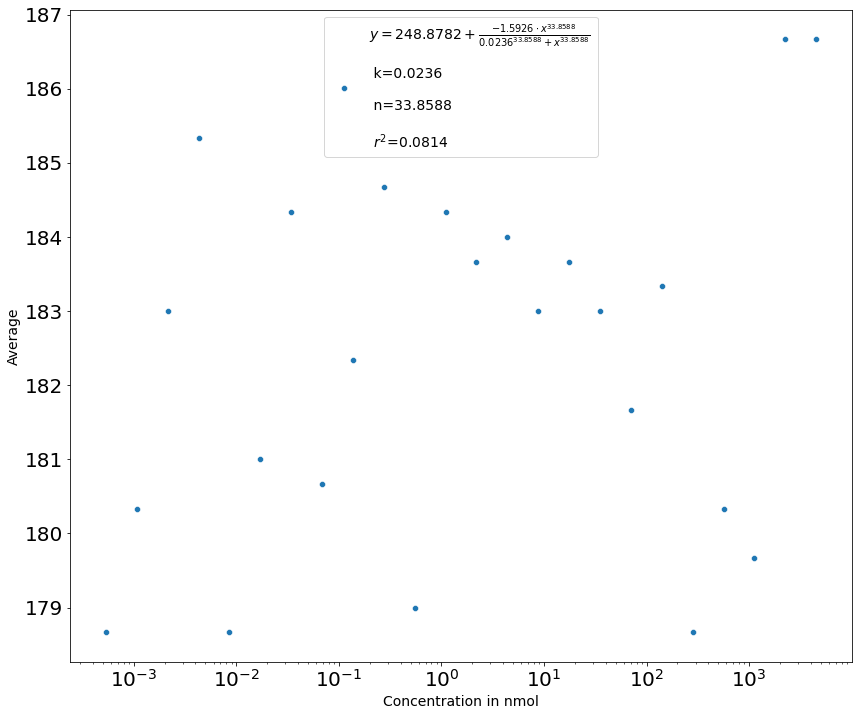

In [47]:
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot()
#fig, ax= plt.subplots()

splot = sns.scatterplot(data=df2, 
                        x='Concentration in nmol',
                        y="Average", label = f'$y = {start_1:.4f} + \\frac{{{(start_2)-(end_2):.4f} \cdot x^{{{n_2:.4f}}}}}{{{k_2:.4f}^{{{n_2:.4f}}}+x^{{{n_2:.4f}}}}}$ \n\n k={k_2:.4f} \n\n n={n_2:.4f} \n\n $r^{2}$={r_squared_2:.4f}'
                       )

""""lplot = sns.lineplot(data=df2, 
                 x=x_data_2, 
                 y=equation(x_data_2, start_2, end_2, k_2, n_2),  
                 color='orange',linewidth=3,
                 label = f'$y = {start_1:.4f} + \\frac{{{(start_2)-(end_2):.4f} \cdot x^{{{n_2:.4f}}}}}{{{k_2:.4f}^{{{n_2:.4f}}}+x^{{{n_2:.4f}}}}}$ \n\n k={k_2:.4f} \n\n n={n_2:.4f} \n\n $r^{2}$={r_squared_2:.4f}'
                )"""

ax.set_xscale('log')

#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)


plt.show()

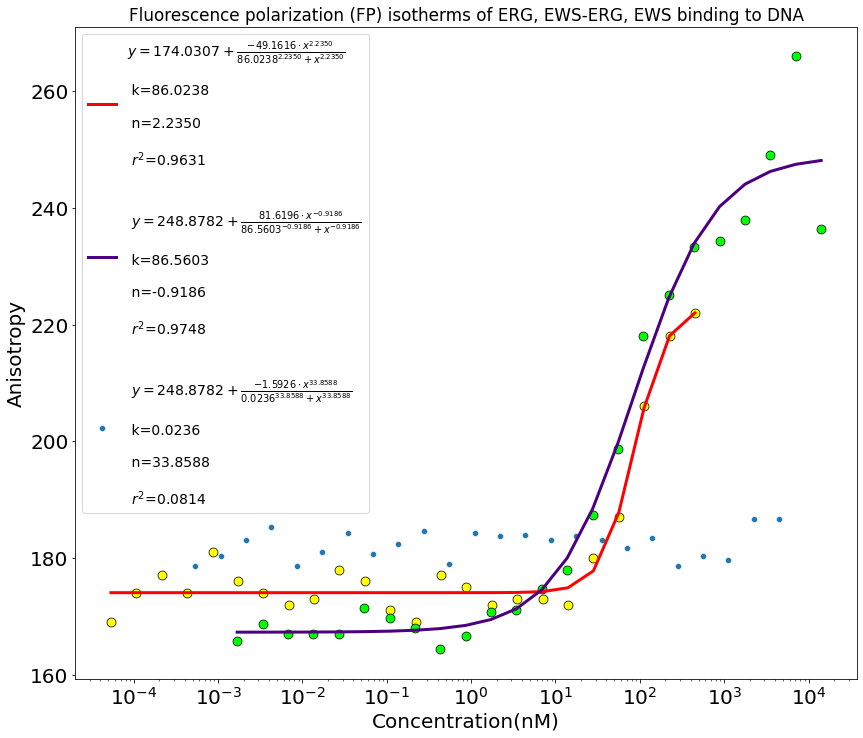

In [62]:
fig = plt.figure(figsize=(14,12),)
ax = fig.add_subplot()
#fig, ax= plt.subplots()ls='', marker='.', ms=3

splot_1 = sns.scatterplot(data=df, 
                        x='Concentration in nmol',
                        y="Average",
                        color = 'yellow',
                        edgecolor='black',
                        s=80
                       )



lplot_1 = sns.lineplot(data=df, 
                x=x_data, 
               y=equation(x_data, start, end, k, n),  
              color='red',linewidth=3,
             label = f'$y = {start:.4f} + \\frac{{{start-end:.4f} \cdot x^{{{n:.4f}}}}}{{{k:.4f}^{{{n:.4f}}}+x^{{{n:.4f}}}}}$ \n\n k={k:.4f} \n\n n={n:.4f} \n\n $r^{2}$={r_squared:.4f}'
             )



splot = sns.scatterplot(data=df1, 
                        x='Concentration in nmol',
                        y="Average",
                         color = 'lime',
                        edgecolor='black',
                        s=80
                       )

lplot = sns.lineplot(data=df1, 
                 x=x_data_1, 
                 y=equation(x_data_1, start_1, end_1, k_1, n_1), 
                 color='#4b0082',linewidth=3,
                 label = f'\n\n $y = {start_1:.4f} + \\frac{{{(start_1)-(end_1):.4f} \cdot x^{{{n_1:.4f}}}}}{{{k_1:.4f}^{{{n_1:.4f}}}+x^{{{n_1:.4f}}}}}$ \n\n k={k_1:.4f} \n\n n={n_1:.4f} \n\n $r^{2}$={r_squared_1:.4f}'
                )

splot = sns.scatterplot(data=df2, 
                        x='Concentration in nmol',
                        y="Average", 
                        label = f'\n\n $y = {start_1:.4f} + \\frac{{{(start_2)-(end_2):.4f} \cdot x^{{{n_2:.4f}}}}}{{{k_2:.4f}^{{{n_2:.4f}}}+x^{{{n_2:.4f}}}}}$ \n\n k={k_2:.4f} \n\n n={n_2:.4f} \n\n $r^{2}$={r_squared_2:.4f}'
                        #edgecolor='black',
                       )


ax.set_xscale('log')



matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
plt.rcParams['font.size'] = '14'



#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)

# Add title and axis names
plt.title('Fluorescence polarization (FP) isotherms of ERG, EWS-ERG, EWS binding to DNA')
plt.ylabel("Anisotropy", size = 20)
plt.xlabel("Concentration(nM)", size = 20)
plt.show()

#save the plot
#plt.savefig('plot.jpg', dpi=300, bbox_inches='tight')
fig.savefig('ax_figure.png')

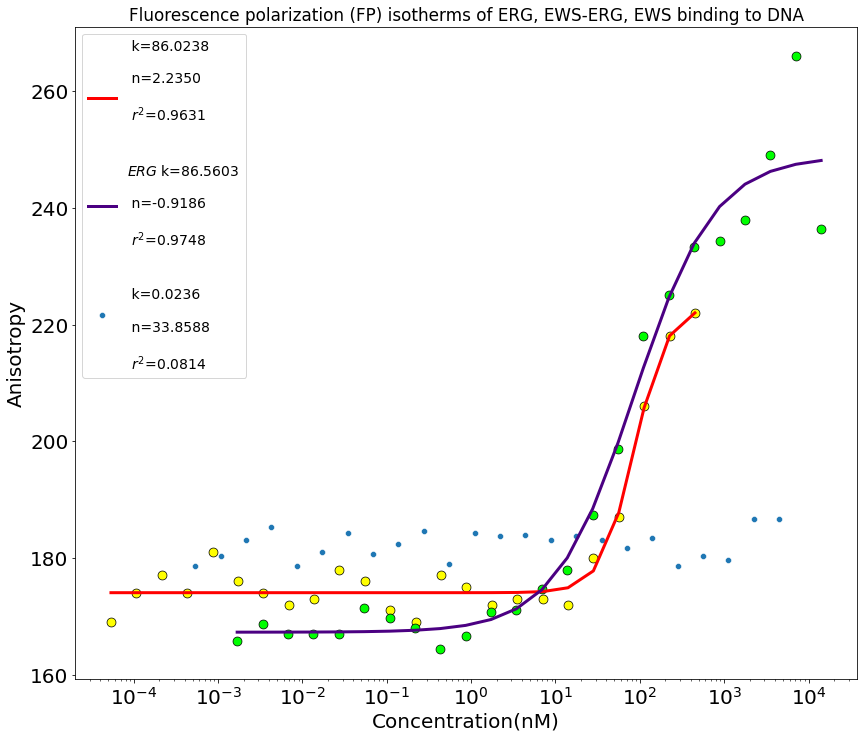

In [70]:
fig = plt.figure(figsize=(14,12),)
ax = fig.add_subplot()
#fig, ax= plt.subplots()ls='', marker='.', ms=3

splot_1 = sns.scatterplot(data=df, 
                        x='Concentration in nmol',
                        y="Average",
                        color = 'yellow',
                        edgecolor='black',
                        s=80
                       )



lplot_1 = sns.lineplot(data=df, 
                x=x_data, 
               y=equation(x_data, start, end, k, n),  
              color='red',linewidth=3,
             label = f' k={k:.4f} \n\n n={n:.4f} \n\n $r^{2}$={r_squared:.4f}\n\n'
             )



splot = sns.scatterplot(data=df1, 
                        x='Concentration in nmol',
                        y="Average",
                         color = 'lime',
                        edgecolor='black',
                        s=80
                       )

lplot = sns.lineplot(data=df1, 
                 x=x_data_1, 
                 y=equation(x_data_1, start_1, end_1, k_1, n_1), 
                 color='#4b0082',linewidth=3,
                 label = f'$ERG$ k={k_1:.4f} \n\n n={n_1:.4f} \n\n $r^{2}$={r_squared_1:.4f}'
                )

splot = sns.scatterplot(data=df2, 
                        x='Concentration in nmol',
                        y="Average", 
                        label = f'\n\n k={k_2:.4f} \n\n n={n_2:.4f} \n\n $r^{2}$={r_squared_2:.4f}'
                        #edgecolor='black',
                       )


ax.set_xscale('log')



matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
plt.rcParams['font.size'] = '14'



#Setting ticks for x axis
x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 10)
ax.xaxis.set_major_locator(x_major)
x_minor = matplotlib.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 10)
ax.xaxis.set_minor_locator(x_minor)

# Add title and axis names
plt.title('Fluorescence polarization (FP) isotherms of ERG, EWS-ERG, EWS binding to DNA')
plt.ylabel("Anisotropy", size = 20)
plt.xlabel("Concentration(nM)", size = 20)
plt.show()

#save the plot
#plt.savefig('plot.jpg', dpi=300, bbox_inches='tight')
#fig.savefig('ax_figure.png')